In [20]:
# ==========================================
# 1. Standard Library & Basic Imports
# ==========================================
import os
import re
import json
import asyncio
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import praw
import ast
import chromadb
import random
import nest_asyncio
import operator

# ==========================================
# 2. From Imports (Specific Modules)
# ==========================================

from dotenv import load_dotenv
from typing import Annotated, List, TypedDict
from datetime import datetime
from tqdm.auto import tqdm
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

from openai import AsyncOpenAI

import chromadb
from chromadb.utils import embedding_functions
from langchain_community.vectorstores import Chroma

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

nest_asyncio.apply()
load_dotenv()

True

In [21]:
# ==========================================
# 3. Environment Setting
# ==========================================

# Reddit
client_id     = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")
user_agent    = os.getenv("USER_AGENT")

reddit = praw.Reddit(
    client_id     = client_id,
    client_secret = client_secret,
    user_agent    = user_agent
)

# LLM 모델
llm = ChatOpenAI(
    model        = "gpt-5.1",
    model_kwargs = {"service_tier": "flex"},
    temperature  = 0,
    api_key      = os.getenv("OPENAI_API_KEY"),
    response_format = {"type": "json_object"}
)

# 임베딩 모델
embeddings = OpenAIEmbeddings()

# ── 변경: ChromaDB를 Purpose별로 분리 ──
# 기존: 단일 컬렉션 → Professional/Casual CR이 섞여 RAG 오염
# 변경: Purpose마다 독립 컬렉션 → 세그먼트별 RAG 정확도 향상
PURPOSES   = ["Professional", "Casual"]
BATCH_SIZE = 20  # 한 번에 LLM에 전달할 리뷰 수

vector_dbs = {
    purpose: Chroma(
        collection_name    = f"cr_{purpose.lower()}",
        embedding_function = embeddings,
        persist_directory  = f"./chroma_db_{purpose.lower()}"
    )
    for purpose in PURPOSES
}

c:\Users\108\Documents\연구 관련\MS_RESEARCH\MS_Proj\MS_Proj_Env\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3641: UserWarning: WARNING! response_format is not default parameter.
                response_format was transferred to model_kwargs.
                Please confirm that response_format is what you intended.
  if await self.run_code(code, result, async_=asy):
c:\Users\108\Documents\연구 관련\MS_RESEARCH\MS_Proj\MS_Proj_Env\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3641: UserWarning: Parameters {'service_tier'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [22]:
# ==========================================
# 4. Class and Function Definitions
# ==========================================

# ── Phase 1 GraphState: 행별 Tagging (기존과 동일) ──
class TaggingState(TypedDict):
    raw_review:       str
    is_valid:         bool
    primary_purpose:  str
    designer_action:  str
    reasoning:        str
    purpose_signals:  List[str]
    evidence_snippet: str


# ── Phase 2 GraphState: 배치 단위 CR Extraction ──
class ExtractionState(TypedDict):
    purpose:             str
    reviews:             List[str]   # 배치 내 리뷰 목록
    designer_actions:    List[str]   # 배치 내 designer_action 목록
    existing_knowledge:  str         # ChromaDB 조회 결과
    extracted_crs:       List[dict]
    cr_inventory:        Annotated[List[str], operator.add]


# --------------------------------------------------
# [Phase 1] Tagging (기존과 동일)
# --------------------------------------------------
def get_openai_tags(review_text):
    system_instruction = """
        ### Role: Senior NPD Research Data Auditor

        Your sole mission is to determine if a review is "Actionable Product Feedback"
        and classify its usage purpose.

        ## Step 1. Validity Check (is_valid):
        Do NOT look for noise patterns. Instead, ask yourself:

        "Can I complete this sentence from this review?
        'A product designer should [do X] because this user needs [Y].'"

        - If YES → proceed to Step 2
        - If NO  → is_valid: false, primary_purpose: "None", stop here

        A valid review must satisfy ALL of the following:
        1. It is a self-contained statement (not a reply fragment or conversation).
        2. It expresses a concrete preference, expectation, or complaint about
        the product's design, performance, or ergonomics.
        3. A product designer can extract a concrete requirement from it.
        The primary intent is NOT to seek help, ask for recommendations,
        or get answers from other users.

        ## Step 2. Evidence Collection (BEFORE assigning purpose):
        List the specific signals in the review that indicate Professional or Casual intent.

        - You MUST find at least 2 concrete, distinct signals to assign a purpose.
        - If you cannot find 2 signals, set primary_purpose: "None", is_valid: false.

        Signals for **Professional**:
            The laptop is used as a tool for specialized, skill-based work
            where performance directly impacts output quality or productivity.
            (e.g., software dev, data science, 4K editing, 3D rendering,
            heavy corporate multitasking, engineering tools, etc.)

        Signals for **Casual**:
            The laptop is used primarily for consumption, communication,
            or light tasks without domain-specific performance demands.
            (e.g., web browsing, streaming, social media,
            basic student homework, everyday home use, etc.)

        ## Step 3. Confidence Check:
        Ask yourself: "If I read this review 10 times, would I assign
        the same purpose every time with >90% certainty?"

        - If YES → assign the purpose
        - If NO, or if Professional and Casual signals are mixed/equal →
        primary_purpose: "None", is_valid: false

        ## Output Schema (JSON Only):
        Important: Fill in "purpose_signals" BEFORE deciding "primary_purpose".
        {
            "purpose_signals": ["signal 1 from the review", "signal 2 from the review"],
            "is_valid": boolean,
            "primary_purpose": "Professional" | "Casual" | "None",
            "designer_action": "Complete the sentence: 'A designer should [X] because this user needs [Y].' Leave empty string if is_valid is false.",
            "reasoning": "One sentence explaining the validity and purpose decision.",
            "evidence_snippet": "The most relevant quote. Empty string if invalid."
        }
    """
    try:
        response = llm.invoke([
            SystemMessage(content=system_instruction),
            HumanMessage(content=f'Review: "{review_text}"')
        ])
        return response.content
    except Exception as e:
        print(f"Error: {e}")
        return None


def tagging_node(state: TaggingState):
    print(f"\n--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---")
    response_content = get_openai_tags(state["raw_review"])
    try:
        result = json.loads(
            response_content.replace("```json", "").replace("```", "").strip()
        )
        return {
            "is_valid":         result.get("is_valid", False),
            "primary_purpose":  result.get("primary_purpose", "None"),
            "designer_action":  result.get("designer_action", ""),
            "reasoning":        result.get("reasoning", ""),
            "purpose_signals":  result.get("purpose_signals", []),
            "evidence_snippet": result.get("evidence_snippet", "")
        }
    except Exception as e:
        print(f"Tagging 노드 결과 파싱 중 오류 발생: {e}")
        return {
            "is_valid": False, "primary_purpose": "None",
            "designer_action": "", "reasoning": f"JSON Parsing Error: {str(e)}",
            "purpose_signals": [], "evidence_snippet": ""
        }


def should_continue(state: TaggingState):
    return "continue" if state["is_valid"] else "end"


# --------------------------------------------------
# [Phase 2] CR Extraction (배치 방식)
# --------------------------------------------------
def get_cr_extraction_prompt(purpose, existing_knowledge):
    return f"""
        ### Identity: The Voice of the "{purpose}" User Group
        You are the representative of the "{purpose}" community. You understand their
        lifestyle, daily challenges, and the specific performance standards they demand
        from a laptop.

        ### Reference Knowledge (Existing Memory):
        The following terms are already standardized in our database. If the current
        reviews' needs match any of these semantically, you MUST use the exact same
        term to ensure data consistency:
        {existing_knowledge if existing_knowledge else "No existing terms yet."}

        ### Mission:
        Read the following review batch (each review prefixed with [R#]) and extract
        **Atomic Customer Requirements (CR)** representing the collective needs of
        the "{purpose}" segment.

        ### CR Extraction Rules (Strict):
        1. **Segment-Level, Not Review-Level**: Identify COMMON or REPRESENTATIVE needs
           across the batch. Do NOT extract a CR for every single sentence.
        2. **Atomic & Single-Intent**: Each CR must contain only ONE specific need.
           If a review mentions weight and battery, split into two separate CRs.
        3. **Noun-Phrase Format**: Use short, punchy noun phrases. No full sentences.
        4. **Exclude Reasons & Context**: Put all supporting context in evidence_summary.
        5. **Objective Translation**: Convert subjective feedback into objective standards.
        6. **Term Consistency (CRITICAL)**: Prioritize mapping to Reference Knowledge
           before creating a new term.
        7. **No CR is valid**: If a review is too vague or has no actionable requirement,
           do NOT force a CR. It is perfectly fine to extract 0 CRs from some reviews.
        8. **Deduplication**: If multiple reviews mention the same need,
           consolidate into ONE CR with aggregated evidence.

        ### Examples:
        - ❌ Bad: "Lightweight chassis under 1.5kg for better portability during commute."
        - ✅ Good: "Body weight (under 1.5kg)"
        - ❌ Bad: "High-resolution screen with good color for photo editing."
        - ✅ Good: "Display color accuracy (DCI-P3 coverage)"

        ### Output Schema (JSON only):
        {{
            "representative_persona": "Brief identity as a {purpose} user",
            "requirements": [
                {{
                    "requirement": "Atomic noun-phrase label (e.g., 'Battery life', 'Fan noise')",
                    "is_mapped_from_memory": false,
                    "supporting_reviews": ["R1", "R3"],
                    "evidence_summary": "Short aggregated summary of what users said"
                }}
            ]
        }}
    """


def rag_node(state: ExtractionState):
    """Purpose별 ChromaDB에서 기존 CR을 검색합니다."""
    purpose    = state["purpose"]
    reviews    = state["reviews"]
    db         = vector_dbs[purpose]
    batch_text = " ".join(reviews[:10])
    try:
        related_docs = db.similarity_search(batch_text, k=7)
        existing     = "\n".join([f"- {doc.page_content}" for doc in related_docs])
    except Exception as e:
        print(f"Chroma DB 검색 중 알림: {e}")
        existing = ""
    return {"existing_knowledge": existing}


def extraction_node(state: ExtractionState):
    """배치 내 리뷰 전체를 한 번에 받아 세그먼트 수준 CR을 추출합니다."""
    purpose            = state["purpose"]
    reviews            = state["reviews"]
    designer_actions   = state["designer_actions"]
    existing_knowledge = state["existing_knowledge"]

    print(f"--- [에이전트: Extractor] {purpose} / {len(reviews)}개 리뷰 배치 분석 ---")

    numbered_reviews = "\n\n".join([f"[R{i+1}] {r}" for i, r in enumerate(reviews)])
    actions_summary  = "\n".join([f"- {a}" for a in designer_actions if a])

    system_prompt = get_cr_extraction_prompt(purpose, existing_knowledge)
    user_prompt   = (
        f"### Design Guidance Summary:\n{actions_summary}\n\n"
        f"### Reviews to Analyze ({len(reviews)} reviews):\n{numbered_reviews}"
    )

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ])
        content = response.content.replace("```json", "").replace("```", "").strip()
        result  = json.loads(content)

        new_requirements = result.get("requirements", [])

        # 신규 CR만 Purpose별 ChromaDB에 저장
        new_terms = [
            req["requirement"]
            for req in new_requirements
            if not req.get("is_mapped_from_memory", True)
        ]
        if new_terms:
            vector_dbs[purpose].add_texts(
                new_terms,
                metadatas=[{"purpose": purpose}] * len(new_terms)
            )
            print(f">>> [Memory/{purpose}] {len(new_terms)}개 신규 CR 등록")

        return {
            "extracted_crs": new_requirements,
            "cr_inventory":  [req["requirement"] for req in new_requirements]
        }

    except Exception as e:
        print(f"Extraction 노드 오류 ({purpose}): {e}")
        return {"extracted_crs": []}

In [23]:
# ==========================================
# 5. Workflow Construction
# ==========================================

# ── Phase 1 Workflow: Tagging (행별, 기존과 동일) ──
tagging_workflow = StateGraph(TaggingState)
tagging_workflow.add_node("Tagger", tagging_node)
tagging_workflow.set_entry_point("Tagger")
tagging_workflow.add_conditional_edges(
    "Tagger",
    should_continue,
    {"continue": END, "end": END}
)
tagging_app = tagging_workflow.compile()

# ── Phase 2 Workflow: CR Extraction (배치, RAG → Extraction) ──
extraction_workflow = StateGraph(ExtractionState)
extraction_workflow.add_node("RAG",        rag_node)
extraction_workflow.add_node("Extraction", extraction_node)
extraction_workflow.set_entry_point("RAG")
extraction_workflow.add_edge("RAG", "Extraction")
extraction_workflow.add_edge("Extraction", END)
extraction_app = extraction_workflow.compile()

In [5]:
raw_data = pd.read_excel('../Data/raw_data/reddit_reviews_03.xlsx')
raw_data = raw_data[:1000]
raw_data.shape

(1000, 5)

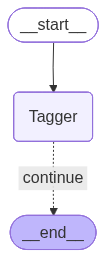

In [6]:
tagging_app

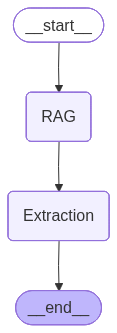

In [7]:
extraction_app

In [8]:
raw_data.head(3)

,Post_ID,Type,Body,Date,URL
0,7eon9l,Comment,It is normal that there isn't a place to chat?,2022-01-21 03:54:04,https://www.reddit.com/r/laptops/comments/7eon...
1,7eon9l,Comment,How do i get the verify button? It doesn't apper.,2021-11-22 10:14:07,https://www.reddit.com/r/laptops/comments/7eon...
2,7eon9l,Comment,Any recommendations for laptops mainly for onl...,2022-03-17 10:25:31,https://www.reddit.com/r/laptops/comments/7eon...


In [ ]:
# ==========================================
# 6. Execution
# ==========================================

# ── Phase 1: Tagging (행별 처리, 기존과 동일) ──
tagging_results = []

for i, review in enumerate(tqdm(raw_data['Body'], desc="[Phase 1] Tagging")):
    try:
        final_state = tagging_app.invoke({"raw_review": review})
        tagging_results.append({
            "Index":           i,
            "Original_Review": review,
            "Is_Valid":        final_state.get("is_valid", False),
            "Purpose":         final_state.get("primary_purpose", "None"),
            "Reasoning":       final_state.get("reasoning", ""),
            "Designer_Action": final_state.get("designer_action", ""),
            "Evidence":        final_state.get("evidence_snippet", "")
        })
    except Exception as e:
        print(f"\n[Error] 인덱스 {i} 처리 중 중단: {e}")
        tagging_results.append({
            "Index": i, "Original_Review": review,
            "Is_Valid": False, "Purpose": "None",
            "Reasoning": f"Error: {e}",
            "Designer_Action": "", "Evidence": ""
        })

tagging_df = pd.DataFrame(tagging_results)

print("\n[Phase 1 완료] Purpose 분포:")
print(tagging_df[tagging_df['Is_Valid'] == True]['Purpose'].value_counts())

[Phase 1] Tagging:   0%|          | 0/1000 [00:00<?, ?it/s]


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging:   0%|          | 1/1000 [00:02<42:41,  2.56s/it]


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging:   0%|          | 2/1000 [00:04<39:22,  2.37s/it]

...


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging: 100%|█████████▉| 999/1000 [29:30<00:01,  1.66s/it]


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging: 100%|██████████| 1000/1000 [29:32<00:00,  1.77s/it]


[Phase 1 완료] Purpose 분포:
Purpose
Casual          72
Professional    50
None             4
Name: count, dtype: int64


In [24]:
tagging_df = pd.read_excel('../Data/Preprocessed_data/reddit_reviews_tagged_agent_driven_01.xlsx')
tagging_df.head()

,Index,Original_Review,Is_Valid,Purpose,Reasoning,Designer_Action,Evidence
0,0,It is normal that there isn't a place to chat?,False,NaN,The review is a question about a missing chat ...,NaN,It is normal that there isn't a place to chat?
1,1,How do i get the verify button? It doesn't apper.,False,NaN,The text is a help request about a missing but...,NaN,How do i get the verify button? It doesn't apper.
2,2,Any recommendations for laptops mainly for onl...,False,NaN,"The text is a request for recommendations, not...",NaN,NaN
3,3,I found a lenovo gaming laptop with a 3060 GPU...,False,NaN,This is a purchase/help question about whether...,NaN,Is it worth buying it and if so how simple is ...
4,4,Alright I have narrowed it down to TWO laptops...,False,NaN,This is a request for buying advice with no ac...,NaN,“I am a beginner so I just need something port...


In [25]:
# ── Phase 2: CR Extraction (Purpose별 배치 처리) ──
cr_results = {purpose: [] for purpose in PURPOSES}

for purpose in PURPOSES:
    segment_df = tagging_df[
        (tagging_df["Is_Valid"] == True) &
        (tagging_df["Purpose"] == purpose)
    ].reset_index(drop=True)

    total = len(segment_df)
    print(f"\n[Phase 2] {purpose} 세그먼트: {total}개 리뷰")

    if total == 0:
        print(f"  → valid 리뷰 없음, 스킵")
        continue

    num_batches = (total + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in tqdm(range(num_batches), desc=f"{purpose} 배치"):
        start = batch_idx * BATCH_SIZE
        end   = min(start + BATCH_SIZE, total)
        batch = segment_df.iloc[start:end]

        final_state = extraction_app.invoke({
            "purpose":             purpose,
            "reviews":             batch["Original_Review"].tolist(),
            "designer_actions":    batch["Designer_Action"].tolist(),
            "existing_knowledge":  "",
            "extracted_crs":       [],
            "cr_inventory":        []
        })

        batch_crs = final_state.get("extracted_crs", [])
        for cr in batch_crs:
            cr["purpose"]     = purpose
            cr["batch_idx"]   = batch_idx
            cr["batch_range"] = f"{start}~{end-1}"

        cr_results[purpose].extend(batch_crs)

    print(f"  → {purpose} 완료: 총 {len(cr_results[purpose])}개 CR")

print("\n[Phase 2 완료]")
for p, crs in cr_results.items():
    print(f"  {p}: {len(crs)}개")


[Phase 2] Professional 세그먼트: 50개 리뷰


Professional 배치:   0%|          | 0/3 [00:00<?, ?it/s]

--- [에이전트: Extractor] Professional / 20개 리뷰 배치 분석 ---


Professional 배치:  33%|███▎      | 1/3 [00:26<00:53, 26.63s/it]

>>> [Memory/Professional] 19개 신규 CR 등록
--- [에이전트: Extractor] Professional / 20개 리뷰 배치 분석 ---


...

>>> [Memory/Casual] 8개 신규 CR 등록
--- [에이전트: Extractor] Casual / 20개 리뷰 배치 분석 ---


Casual 배치:  75%|███████▌  | 3/4 [00:59<00:19, 19.24s/it]

>>> [Memory/Casual] 17개 신규 CR 등록
--- [에이전트: Extractor] Casual / 12개 리뷰 배치 분석 ---


Casual 배치: 100%|██████████| 4/4 [01:10<00:00, 17.56s/it]

>>> [Memory/Casual] 8개 신규 CR 등록
  → Casual 완료: 총 74개 CR

[Phase 2 완료]
  Professional: 70개
  Casual: 74개


In [ ]:
# ==========================================
# 7. 결과 저장
# ==========================================

# Phase 1: Tagging 결과
tagging_df.to_excel(
    '../Data/Preprocessed_data/reddit_reviews_tagged_agent_driven_010.xlsx',
    index=False
)

In [26]:
# Phase 2: CR Extraction 결과 (Purpose별 시트 분리)
cr_output_path = '../Data/CR_Extraction/agent_drive_cr_extraction_02.xlsx'
with pd.ExcelWriter(cr_output_path, engine='openpyxl') as writer:
    for purpose, crs in cr_results.items():
        if crs:
            cr_df = pd.DataFrame(crs)
            if "supporting_reviews" in cr_df.columns:
                cr_df["supporting_reviews"] = cr_df["supporting_reviews"].apply(
                    lambda x: ", ".join(x) if isinstance(x, list) else str(x)
                )
            cr_df.to_excel(writer, sheet_name=purpose, index=False)

print(f"저장 완료: {cr_output_path}")

저장 완료: ../Data/CR_Extraction/agent_drive_cr_extraction_02.xlsx


In [ ]:
# ChromaDB 확인
for purpose in PURPOSES:
    print(f"chroma_db_{purpose.lower()}: {os.path.exists(f'./chroma_db_{purpose.lower()}')}")

In [ ]:
# 결과 확인
for purpose, crs in cr_results.items():
    print(f"\n{'='*40}")
    print(f"  {purpose} ({len(crs)}개 CR)")
    print(f"{'='*40}")
    for i, cr in enumerate(crs, 1):
        print(f"  [{i:02d}] {cr['requirement']}")